## Custom Data Generator

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
import sys
sys.path.append("../training")

from data_generator import DataGenerator

In [3]:
DATA_DIR = "../data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
CSV_PATH = os.path.join(DATA_DIR, "train_solution_bounding_boxes.csv")

In [4]:
df = pd.read_csv(CSV_PATH)

df["image_path"] = df["image"].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

print(len(train_df), len(val_df))

447 112


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16

In [6]:
class DataGenerator(tf.keras.utils.Sequence):
    
    def __init__(self, dataframe, batch_size, augment=False):
        self.df = dataframe
        self.batch_size = batch_size
        self.augment = augment
        
    def __len__(self):
        return len(self.df) // self.batch_size
    
    def __getitem__(self, index):
        
        batch = self.df.iloc[
            index*self.batch_size:(index+1)*self.batch_size
        ]
        
        images = []
        bboxes = []
        
        for _, row in batch.iterrows():
            
            img = cv2.imread(row.image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            h, w, _ = img.shape
            
            xmin = row.xmin / w
            ymin = row.ymin / h
            xmax = row.xmax / w
            ymax = row.ymax / h
            
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            
            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                    xmin, xmax = 1 - xmax, 1 - xmin
            
            bbox = [xmin, ymin, xmax, ymax]
            
            images.append(img)
            bboxes.append(bbox)
        
        return np.array(images), np.array(bboxes)

In [7]:
train_generator = DataGenerator(
    train_df,
    BATCH_SIZE,
    augment=True
)

val_generator = DataGenerator(
    val_df,
    BATCH_SIZE,
    augment=False
)

print(len(train_generator), len(val_generator))

27 7


In [8]:
images, boxes = train_generator[0]

print(images.shape)
print(boxes.shape)

(16, 224, 224, 3)
(16, 4)


In [9]:
def visualize_batch(images, boxes):
    
    plt.figure(figsize=(12,12))
    
    for i in range(4):
        
        img = images[i]
        box = boxes[i]
        
        h, w, _ = img.shape
        
        xmin = int(box[0] * w)
        ymin = int(box[1] * h)
        xmax = int(box[2] * w)
        ymax = int(box[3] * h)
        
        img = (img * 255).astype(np.uint8)
        
        cv2.rectangle(
            img,
            (xmin, ymin),
            (xmax, ymax),
            (255,0,0),
            2
        )
        
        plt.subplot(2,2,i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.show()

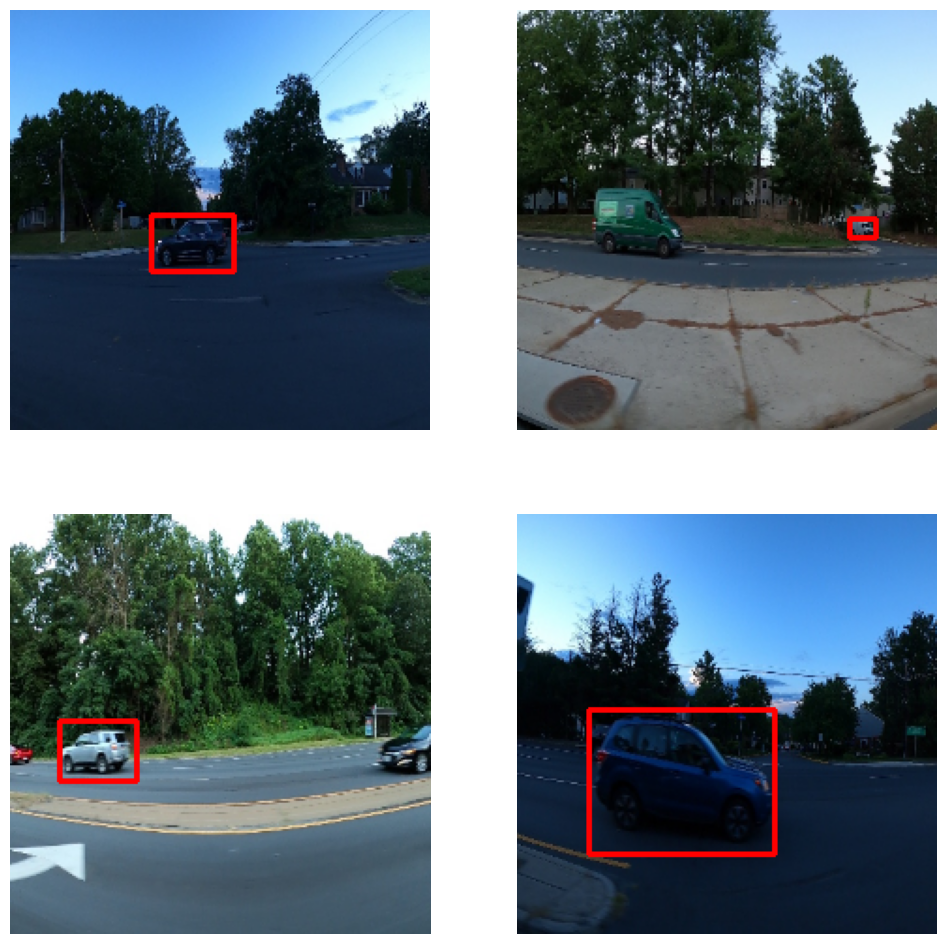

In [10]:
visualize_batch(images, boxes)

In [12]:
batch = train_generator[0]
images, boxes = batch

print("First 10 bounding boxes:\n")
for i in range(10):
    print(boxes[i])

First 10 bounding boxes:

[0.33719247 0.48962355 0.53183792 0.62347169]
[0.14544139 0.49605856 0.20839363 0.5411036 ]
[0.12011577 0.49219755 0.29956585 0.6363417 ]
[0.3878437  0.46517053 0.82995658 0.81137387]
[0.19971056 0.47289254 0.3552822  0.57585264]
[0.24544792 0.47267649 0.42680262 0.61775421]
[0.87771346 0.50378057 1.         0.62475869]
[0.18017366 0.52051158 0.33936324 0.6363417 ]
[0.30824891 0.47031853 0.53617945 0.61574968]
[0.73589001 0.48447555 0.93777135 0.60802767]
